In [9]:
import sys, os
import pandas as pd
sys.path.append(os.path.join(os.getcwd(), '..'))
import utils.classifiers as classifiers
import utils.normalizer as normalizer
import data_getter

dg = data_getter.get_data_getter({
    "type": "csv",
    "data_dir": os.path.join(os.environ['HOME'], 'git/pyAnomalyDetector/tests/testdata/csv/20250410_0800'),
})

endep = int(1744236001) # 2025-04-07 08:00:00
t_endep = int(endep - 3600 * 12)
startep = t_endep
t_startep = int(t_endep - 3600 * 24 * 1)
itemIds = [142038,223147,226179,227721,227722,227723,227724,227725,233863,
           233974,234653,235433,235439,236474,236605,240454,246279,360736]

#itemIds = [227721, 227722, 227723, 227724, 227725, 234653, 236605]

t_data = dg.get_trends_data(t_startep, t_endep, itemIds) # pd.DataFrame
h_data = dg.get_history_data(startep, endep, itemIds) # pd.DataFrame

print(h_data['clock'].max())
print(h_data['clock'].min())

chart_stats = normalizer.get_chart_stats(t_data, itemIds) 
charts, _ = normalizer.df2charts(h_data, itemIds)



1744235992
1744192807


In [10]:
clusters, centroids, charts = classifiers.run_dbscan(charts, chart_stats,min_samples=2,
                                                     jaccard_eps=0.2, corr_eps=0.3, sigma=2.0)
#clusters = classifiers.reassign_charts(charts, clusters, centroids, 0.5)

#score = classifiers.evaluate_clusters(charts, clusters)
#print("score: ", score)

/home/ubuntu/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ubuntu/.local/lib/python3.10/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [11]:
view_source = {
    "name": "views_20250407",
    "type": "csv",
    "history_file_path": os.path.join(dg.data_dir, "history.csv.gz"),
    "trends_file_path": os.path.join(dg.data_dir, "trends.csv.gz"),
    "startep": startep,
    "endep": endep
}
import views


def plot_charts(itemIds):
    df = pd.DataFrame(itemIds, columns=['itemid'])
    v = views.get_view(view_source)
    v.show(df)

    
classes = {}
for chart_id, cluster_id in clusters.items():
    if cluster_id not in classes:
        classes[cluster_id] = []
    classes[cluster_id].append(chart_id)
print("classes: ", classes)

classes:  {-1: [142038, 223147, 226179, 233863, 233974, 234653, 236474, 236605, 240454, 246279, 360736], 3: [227721, 227722, 227723, 227724, 227725], 4: [235433, 235439]}


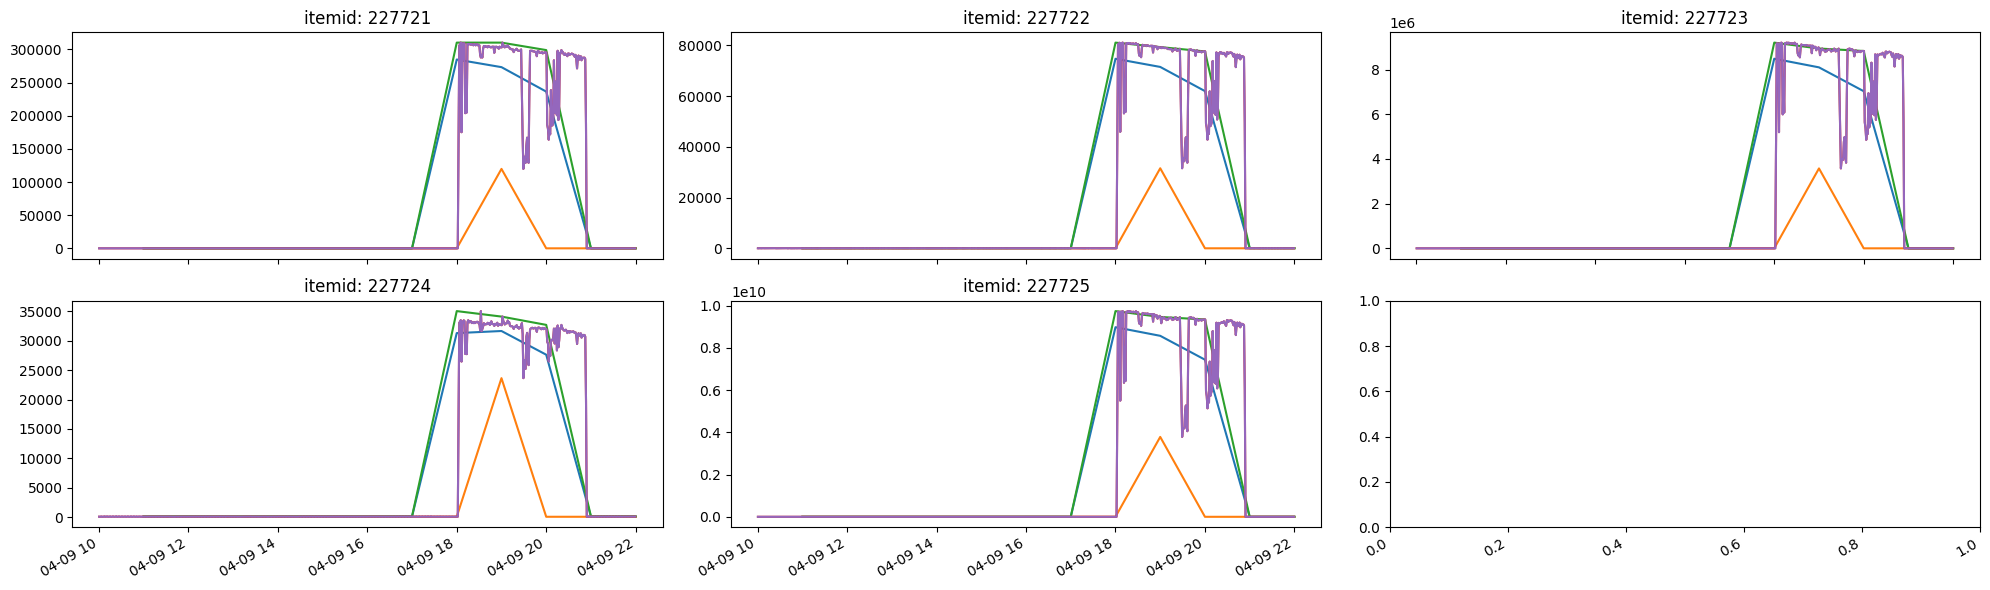

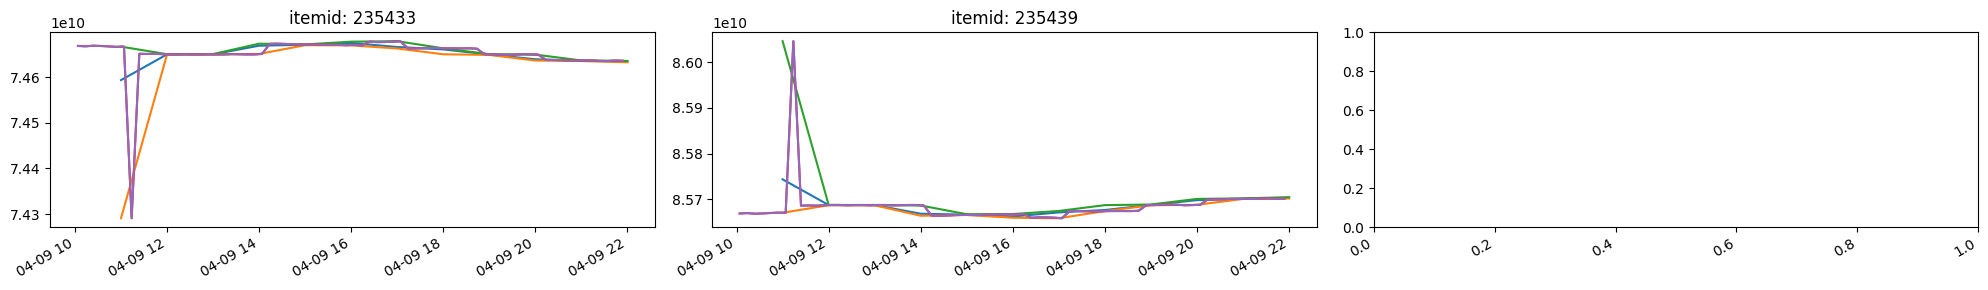

KeyError: 5

In [13]:
#plot_charts(classes[0])
#plot_charts(classes[1])
#plot_charts(classes[2])
plot_charts(classes[3])
plot_charts(classes[4])
plot_charts(classes[5])
plot_charts(classes[6])
plot_charts(classes[7])